In [5]:
# Import libraries
import pandas as pd
import numpy as np

In [6]:
# Load the Excel workbook
file_path = "../data/NorthBridgeDataset.xlsx"

excel_file = pd.ExcelFile(file_path)

# View all sheet names
excel_file.sheet_names

['README',
 'PriorityLevels',
 'TicketCategories',
 'SLADefinitions',
 'Agents',
 'Clients',
 'Tickets',
 'TicketAuditLog',
 'EscalationLog']

In [7]:
# Load the main tables
tickets = pd.read_excel(file_path, sheet_name="Tickets")
clients = pd.read_excel(file_path, sheet_name="Clients")
agents = pd.read_excel(file_path, sheet_name="Agents")

In [8]:
# Check the size of each table
print("Tickets:", tickets.shape)
print("Clients:", clients.shape)
print("Agents:", agents.shape)

Tickets: (3500, 16)
Clients: (80, 10)
Agents: (120, 8)


In [9]:
# Preview the Tickets table
tickets.head()

,TicketID,TicketReference,ClientID,PatientRef,CategoryID,PriorityID,Status,AssignedAgentID,CreatedAt,FirstResponseAt,ResolvedAt,SLADueAt,SLABreached,Channel,Description,ResolutionNotes
0,1,NB-2024-00001,70,PT-81496,5,3,Closed,111,2024-07-24 23:41,2024-07-25 02:27,2024-07-27 10:35,2024-07-27 23:41,0,Phone,Request for discharge summary for patient PT-8...,Insurance medical report completed and submitt...
1,2,NB-2024-00002,51,PT-99051,2,1,Closed,32,2024-11-06 23:45,2024-11-07 01:09,2024-11-07 04:44,2024-11-07 07:45,0,Portal,Query regarding invoice 28714 dated 09 Oct 202...,Charge dispute investigated. Original amount v...
2,3,NB-2024-00003,53,PT-24869,3,3,Closed,57,2024-08-01 05:39,2024-08-01 09:58,2024-08-02 14:35,2024-08-04 05:39,0,Portal,Pre-authorisation request for outpatient consu...,Pre-auth declined by insurer. Patient advised ...
3,4,NB-2024-00004,11,PT-55537,1,2,Closed,22,2024-12-03 13:22,2024-12-03 14:47,2024-12-04 07:32,2024-12-04 01:22,1,Form,Patient PT-55537 requesting addition of appoin...,Cancellation processed. New appointment booked...
4,5,NB-2023-00005,70,PT-50539,3,2,Resolved,52,2023-02-11 03:56,2023-02-11 06:27,2023-02-11 12:26,2023-02-12 03:56,0,Phone,Pre-authorisation request for surgical procedu...,Pre-authorisation confirmed with insurer. Refe...


In [10]:
# Check column names, data types, and missing values
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TicketID         3500 non-null   int64
 1   TicketReference  3500 non-null   str  
 2   ClientID         3500 non-null   int64
 3   PatientRef       3500 non-null   str  
 4   CategoryID       3500 non-null   int64
 5   PriorityID       3500 non-null   int64
 6   Status           3500 non-null   str  
 7   AssignedAgentID  3500 non-null   int64
 8   CreatedAt        3500 non-null   str  
 9   FirstResponseAt  3454 non-null   str  
 10  ResolvedAt       3301 non-null   str  
 11  SLADueAt         3500 non-null   str  
 12  SLABreached      3500 non-null   int64
 13  Channel          3500 non-null   str  
 14  Description      3500 non-null   str  
 15  ResolutionNotes  3301 non-null   str  
dtypes: int64(6), str(10)
memory usage: 437.6 KB


In [11]:
# Check for duplicate rows
print("Duplicate rows:", tickets.duplicated().sum())

# Check SLA breach distribution
print(tickets["SLABreached"].value_counts())

# Check SLA breach percentage
print(tickets["SLABreached"].value_counts(normalize=True) * 100)

Duplicate rows: 0
SLABreached
0    2746
1     754
Name: count, dtype: int64
SLABreached
0    78.457143
1    21.542857
Name: proportion, dtype: float64


So the target is imbalanced, but not horribly imbalanced. About 1 out of every 5 tickets breached its SLA.

In [12]:
# Check missing values in the Tickets table
tickets.isnull().sum()

TicketID             0
TicketReference      0
ClientID             0
PatientRef           0
CategoryID           0
PriorityID           0
Status               0
AssignedAgentID      0
CreatedAt            0
FirstResponseAt     46
ResolvedAt         199
SLADueAt             0
SLABreached          0
Channel              0
Description          0
ResolutionNotes    199
dtype: int64

In [13]:
# Check ticket status distribution
tickets["Status"].value_counts()

Status
Closed            1984
Resolved          1317
Escalated           57
In Progress         52
Open                46
Pending Client      44
Name: count, dtype: int64

In [14]:
# Check the status of tickets with no resolution date
tickets.loc[tickets["ResolvedAt"].isnull(), "Status"].value_counts()

Status
Escalated         57
In Progress       52
Open              46
Pending Client    44
Name: count, dtype: int64

In [15]:
# Check the status of tickets with no first response
tickets.loc[tickets["FirstResponseAt"].isnull(), "Status"].value_counts()

Status
Open    46
Name: count, dtype: int64

Missing values were found only in three columns of the Tickets table:

- `FirstResponseAt` – 46 missing values
- `ResolvedAt` – 199 missing values
- `ResolutionNotes` – 199 missing values

Further investigation showed that all 46 tickets without a `FirstResponseAt` value have a status of `Open`, meaning they have not yet received a first response.

The 199 tickets without a `ResolvedAt` value are still active, with statuses including `Escalated`, `In Progress`, `Open`, and `Pending Client`. These same unresolved tickets also have missing `ResolutionNotes`.

Therefore, the missing values are considered valid operational missingness rather than data-quality errors. No values were filled or removed because doing so would introduce inaccurate information into the dataset.

In [16]:
# Inspect Clients table
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ClientID           80 non-null     int64
 1   ClientName         80 non-null     str  
 2   ClientType         80 non-null     str  
 3   ContractTier       80 non-null     str  
 4   AccountManagerID   80 non-null     int64
 5   Region             80 non-null     str  
 6   ContractStartDate  80 non-null     str  
 7   ContractEndDate    80 non-null     str  
 8   SLACreditClause    80 non-null     int64
 9   IsActive           80 non-null     int64
dtypes: int64(4), str(6)
memory usage: 6.4 KB


In [17]:
# Preview Clients table
clients.head()

,ClientID,ClientName,ClientType,ContractTier,AccountManagerID,Region,ContractStartDate,ContractEndDate,SLACreditClause,IsActive
0,1,Ashworth Medical Centre,Private Hospital,Premium,41,South East,2010-05-01,2013-10-19,0,1
1,2,Unity Health Clinic,Dental Group,Enterprise,92,Midlands,2016-03-01,2018-04-16,0,1
2,3,Junction Health Clinic,Private Hospital,Premium,76,Midlands,2014-08-01,2017-03-27,1,1
3,4,Arcadia Health Group,Mental Health Clinic,Enterprise,59,Yorkshire,2023-11-01,2028-08-12,1,1
4,5,Parkside Specialist Clinic,Private Hospital,Standard,102,Scotland,2014-09-01,2016-05-11,0,1


In [18]:
# Inspect Agents table
agents.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   AgentID        120 non-null    int64
 1   FullName       120 non-null    str  
 2   TeamID         120 non-null    int64
 3   Role           120 non-null    str  
 4   Specialisms    120 non-null    str  
 5   Hub            120 non-null    str  
 6   DailyCapacity  120 non-null    int64
 7   IsActive       120 non-null    int64
dtypes: int64(4), str(4)
memory usage: 7.6 KB


In [19]:
# Preview Agents table
agents.head()

,AgentID,FullName,TeamID,Role,Specialisms,Hub,DailyCapacity,IsActive
0,1,Parveen Szymański,1,Senior Agent,"Document Request,Insurance Query,Appointment C...",Manchester,16,1
1,2,Kirsty Morrison,1,Team Lead,"Document Request,Insurance Query,Complaint",Manchester,11,1
2,3,Alexander Johnson,1,Senior Agent,"Appointment Change,Billing Issue",Manchester,19,1
3,4,Eleanor Patel,1,Agent,"Insurance Query,Complaint",Manchester,19,1
4,5,Aisha Szymański,1,Agent,"Insurance Query,Appointment Change,Document Re...",Manchester,21,1


Do all the ClientID and AssignedAgentID values in Tickets actually exist in the Clients and Agents tables?

In [20]:
# Check for duplicate IDs in Clients and Agents
print("Duplicate Client IDs:", clients["ClientID"].duplicated().sum())
print("Duplicate Agent IDs:", agents["AgentID"].duplicated().sum())

Duplicate Client IDs: 0
Duplicate Agent IDs: 0


In [21]:
# Check for Ticket ClientIDs that do not exist in Clients
missing_clients = set(tickets["ClientID"]) - set(clients["ClientID"])

# Check for Ticket AssignedAgentIDs that do not exist in Agents
missing_agents = set(tickets["AssignedAgentID"]) - set(agents["AgentID"])

print("Unmatched Client IDs:", missing_clients)
print("Unmatched Agent IDs:", missing_agents)

Unmatched Client IDs: set()
Unmatched Agent IDs: set()


What kinds of tickets, clients, and agents actually exist in this dataset?

In [22]:
# Check unique values in key ticket columns
print("Status values:")
print(tickets["Status"].value_counts())

print("\nChannel values:")
print(tickets["Channel"].value_counts())

print("\nPriority IDs:")
print(tickets["PriorityID"].value_counts().sort_index())

print("\nCategory IDs:")
print(tickets["CategoryID"].value_counts().sort_index())

Status values:
Status
Closed            1984
Resolved          1317
Escalated           57
In Progress         52
Open                46
Pending Client      44
Name: count, dtype: int64

Channel values:
Channel
Email     1221
Portal     977
Phone      905
Form       397
Name: count, dtype: int64

Priority IDs:
PriorityID
1     258
2     833
3    1981
4     428
Name: count, dtype: int64

Category IDs:
CategoryID
1    1200
2     873
3     706
4     306
5     415
Name: count, dtype: int64


In [23]:
# Check key client categories
print("Contract Tier:")
print(clients["ContractTier"].value_counts())

print("\nRegion:")
print(clients["Region"].value_counts())

Contract Tier:
ContractTier
Standard      37
Premium       29
Enterprise    14
Name: count, dtype: int64

Region:
Region
Midlands      21
Scotland      13
South East    12
North East    12
Yorkshire     11
North West    11
Name: count, dtype: int64


In [24]:
# Check key agent categories
print("Hub:")
print(agents["Hub"].value_counts())

print("\nRole:")
print(agents["Role"].value_counts())

print("\nDaily Capacity Summary:")
print(agents["DailyCapacity"].describe())

Hub:
Hub
Manchester    42
Leeds         28
Birmingham    28
Edinburgh     22
Name: count, dtype: int64

Role:
Role
Agent                 92
Senior Agent          18
Team Lead              9
Operations Manager     1
Name: count, dtype: int64

Daily Capacity Summary:
count    120.000000
mean      20.925000
std        4.692498
min        6.000000
25%       19.000000
50%       21.000000
75%       24.250000
max       28.000000
Name: DailyCapacity, dtype: float64


Inspect the lookup tables

In [25]:
# Load supporting lookup tables
priority_levels = pd.read_excel(file_path, sheet_name="PriorityLevels")
ticket_categories = pd.read_excel(file_path, sheet_name="TicketCategories")
sla_definitions = pd.read_excel(file_path, sheet_name="SLADefinitions")

In [26]:
# View priority definitions
priority_levels

,PriorityID,PriorityLabel,Description
0,1,P1 Critical,"Immediate risk to patient safety, legal/regula..."
1,2,P2 High,"Significant financial impact, complaint from c..."
2,3,P3 Standard,Routine service request with defined SLA. Stan...
3,4,P4 Low,"Informational queries, minor updates, or reque..."


In [27]:
# View ticket category definitions
ticket_categories

,CategoryID,CategoryName,DefaultPriorityID,RequiresSpecialist,Description
0,1,Appointment Change,3,0,"Request to reschedule, cancel, or add a patien..."
1,2,Billing Issue,2,1,"Disputes, queries, or corrections relating to ..."
2,3,Insurance Query,2,1,"Queries about pre-authorisation, claim status,..."
3,4,Complaint,2,0,Formal or informal patient or client complaint...
4,5,Document Request,3,0,"Requests for medical records, letters, referra..."


In [28]:
# View SLA definitions
sla_definitions

,SLAID,ContractTier,PriorityID,FirstResponseHours,ResolutionHours,EscalationTriggerHours,EffectiveFrom
0,1,Standard,1,2.0,8,6.0,2023-01-01
1,2,Standard,2,4.0,24,20.0,2023-01-01
2,3,Standard,3,8.0,72,60.0,2023-01-01
3,4,Standard,4,24.0,120,100.0,2023-01-01
4,5,Premium,1,1.0,4,3.0,2023-01-01
5,6,Premium,2,2.0,12,10.0,2023-01-01
6,7,Premium,3,4.0,48,40.0,2023-01-01
7,8,Premium,4,12.0,96,80.0,2023-01-01
8,9,Enterprise,1,0.5,2,1.5,2023-01-01
9,10,Enterprise,2,1.0,8,6.0,2023-01-01


Create the modelling table

In [29]:
# Add selected client information to each ticket
model_data = tickets.merge(
    clients[
        [
            "ClientID",
            "ContractTier",
            "SLACreditClause"
        ]
    ],
    on="ClientID",
    how="left"
)

# Add selected agent information to each ticket
model_data = model_data.merge(
    agents[
        [
            "AgentID",
            "TeamID",
            "Hub",
            "DailyCapacity"
        ]
    ],
    left_on="AssignedAgentID",
    right_on="AgentID",
    how="left"
)

# Check the new table size
model_data.shape

(3500, 22)

In [30]:
# Preview the combined modelling dataset
model_data.head()

,TicketID,TicketReference,ClientID,PatientRef,CategoryID,PriorityID,Status,AssignedAgentID,CreatedAt,FirstResponseAt,...,SLABreached,Channel,Description,ResolutionNotes,ContractTier,SLACreditClause,AgentID,TeamID,Hub,DailyCapacity
0,1,NB-2024-00001,70,PT-81496,5,3,Closed,111,2024-07-24 23:41,2024-07-25 02:27,...,0,Phone,Request for discharge summary for patient PT-8...,Insurance medical report completed and submitt...,Standard,0,111,8,Edinburgh,16
1,2,NB-2024-00002,51,PT-99051,2,1,Closed,32,2024-11-06 23:45,2024-11-07 01:09,...,0,Portal,Query regarding invoice 28714 dated 09 Oct 202...,Charge dispute investigated. Original amount v...,Standard,0,32,1,Manchester,8
2,3,NB-2024-00003,53,PT-24869,3,3,Closed,57,2024-08-01 05:39,2024-08-01 09:58,...,0,Portal,Pre-authorisation request for outpatient consu...,Pre-auth declined by insurer. Patient advised ...,Standard,0,57,4,Leeds,21
3,4,NB-2024-00004,11,PT-55537,1,2,Closed,22,2024-12-03 13:22,2024-12-03 14:47,...,1,Form,Patient PT-55537 requesting addition of appoin...,Cancellation processed. New appointment booked...,Premium,1,22,1,Manchester,27
4,5,NB-2023-00005,70,PT-50539,3,2,Resolved,52,2023-02-11 03:56,2023-02-11 06:27,...,0,Phone,Pre-authorisation request for surgical procedu...,Pre-authorisation confirmed with insurer. Refe...,Standard,0,52,4,Leeds,26


In [31]:
# Check for missing values created by the joins
model_data[
    [
        "ContractTier",
        "SLACreditClause",
        "TeamID",
        "Hub",
        "DailyCapacity"
    ]
].isnull().sum()

ContractTier       0
SLACreditClause    0
TeamID             0
Hub                0
DailyCapacity      0
dtype: int64


The Tickets, Clients, and Agents tables were successfully merged to create the modelling dataset.

- The combined dataset contains **3,500 rows and 22 columns**.
- The number of rows remained unchanged after the merge, confirming that no ticket records were lost.
- Client information such as `ContractTier` and `SLACreditClause` was successfully added using `ClientID`.
- Agent information such as `TeamID`, `Hub`, and `DailyCapacity` was added using `AssignedAgentID`.
- No missing values were introduced in the newly joined client and agent features.

This confirms that the relationships between the Tickets, Clients, and Agents tables are valid and the combined dataset is ready for further feature preparation and exploratory analysis.

In [32]:
# Convert ticket creation time to datetime
model_data["CreatedAt"] = pd.to_datetime(model_data["CreatedAt"])

# Check the result
model_data["CreatedAt"].dtype

dtype('<M8[us]')

In [33]:
# Create time-based features from ticket creation date
model_data["CreatedHour"] = model_data["CreatedAt"].dt.hour
model_data["CreatedDayOfWeek"] = model_data["CreatedAt"].dt.day_name()
model_data["CreatedMonth"] = model_data["CreatedAt"].dt.month

In [34]:
model_data[
    ["CreatedAt", "CreatedHour", "CreatedDayOfWeek", "CreatedMonth"]
].head()

,CreatedAt,CreatedHour,CreatedDayOfWeek,CreatedMonth
0,2024-07-24 23:41:00,23,Wednesday,7
1,2024-11-06 23:45:00,23,Wednesday,11
2,2024-08-01 05:39:00,5,Thursday,8
3,2024-12-03 13:22:00,13,Tuesday,12
4,2023-02-11 03:56:00,3,Saturday,2


The `CreatedAt` column was successfully converted from text to datetime format.

Three new time-based features were created from the ticket creation timestamp:

- `CreatedHour` – shows the hour of the day the ticket was created
- `CreatedDayOfWeek` – shows the day of the week the ticket was created
- `CreatedMonth` – shows the month the ticket was created

The preview confirms that these features were extracted correctly. These variables can be used during exploratory analysis to check whether SLA breaches are more common at certain times, on specific days, or during particular months.

In [35]:
# Check whether TicketID contains duplicate values
print("Duplicate Ticket IDs:", tickets["TicketID"].duplicated().sum())

# Check whether TicketReference contains duplicate values
print("Duplicate Ticket References:", tickets["TicketReference"].duplicated().sum())

Duplicate Ticket IDs: 0
Duplicate Ticket References: 0


In [36]:
# Check whether all PriorityIDs in Tickets exist in the PriorityLevels table
invalid_priorities = set(tickets["PriorityID"]) - set(priority_levels["PriorityID"])

# Check whether all CategoryIDs in Tickets exist in the TicketCategories table
invalid_categories = set(tickets["CategoryID"]) - set(ticket_categories["CategoryID"])

print("Invalid Priority IDs:", invalid_priorities)
print("Invalid Category IDs:", invalid_categories)

Invalid Priority IDs: set()
Invalid Category IDs: set()


The identifier and lookup checks were successfully completed.

- `TicketID` contains no duplicate values.
- `TicketReference` contains no duplicate values.
- All `PriorityID` values in the Tickets table match valid records in the PriorityLevels table.
- All `CategoryID` values in the Tickets table match valid records in the TicketCategories table.

This confirms that ticket identifiers are unique and that the priority and category references are consistent across the dataset.

In [38]:
# Convert relevant ticket timestamp columns to datetime format
tickets["CreatedAt"] = pd.to_datetime(tickets["CreatedAt"])
tickets["FirstResponseAt"] = pd.to_datetime(tickets["FirstResponseAt"])
tickets["ResolvedAt"] = pd.to_datetime(tickets["ResolvedAt"])
tickets["SLADueAt"] = pd.to_datetime(tickets["SLADueAt"])

# Check for tickets where the first response occurred before the ticket was created
response_before_creation = (
    tickets["FirstResponseAt"].notna()
    & (tickets["FirstResponseAt"] < tickets["CreatedAt"])
)

# Check for tickets where resolution occurred before the ticket was created
resolution_before_creation = (
    tickets["ResolvedAt"].notna()
    & (tickets["ResolvedAt"] < tickets["CreatedAt"])
)

# Check for tickets where SLA due time occurred before ticket creation
sla_before_creation = (
    tickets["SLADueAt"] < tickets["CreatedAt"]
)

print("First response before creation:", response_before_creation.sum())
print("Resolution before creation:", resolution_before_creation.sum())
print("SLA due before creation:", sla_before_creation.sum())

First response before creation: 0
Resolution before creation: 0
SLA due before creation: 0


The timestamp consistency checks were successfully completed.

- No ticket had a `FirstResponseAt` value earlier than its `CreatedAt` time.
- No ticket had a `ResolvedAt` value earlier than its `CreatedAt` time.
- No ticket had an `SLADueAt` value earlier than its `CreatedAt` time.

This confirms that the ticket timestamps are logically consistent and no invalid date sequences were identified.

## Data Validation Summary

The NorthBridge dataset was reviewed for missing values, duplicates, identifier consistency, table relationships, lookup validity, and timestamp accuracy.

The Tickets table contains 3,500 records with no duplicate rows, while `TicketID` and `TicketReference` are unique. The Clients and Agents tables contain no missing values or duplicate primary IDs.

All client, agent, priority, and category references used in the Tickets table successfully matched their corresponding lookup tables, confirming that the relationships between the datasets are valid.

Missing values were found only in `FirstResponseAt`, `ResolvedAt`, and `ResolutionNotes`. Further investigation showed that these values belong to open or unresolved tickets, so they were retained as valid operational missingness rather than treated as data-quality errors.

The `SLABreached` target is complete, with approximately 21.54% of tickets breaching SLA and 78.46% meeting SLA.

Timestamp checks also confirmed that no first response, resolution, or SLA deadline occurred before the corresponding ticket creation time.

Overall, the core dataset is clean, consistent, and suitable for feature engineering and exploratory data analysis.

### Exploratory Data Analysis (EDA)

In [40]:
# Add readable priority labels to the modelling dataset
model_data = model_data.merge(
    priority_levels[
        [
            "PriorityID",
            "PriorityLabel"
        ]
    ],
    on="PriorityID",
    how="left"
)

# Add readable ticket category names to the modelling dataset
model_data = model_data.merge(
    ticket_categories[
        [
            "CategoryID",
            "CategoryName"
        ]
    ],
    on="CategoryID",
    how="left"
)

# Check the size of the dataset after the joins
model_data.shape

(3500, 27)

In [41]:
# Preview the newly added priority and category labels
model_data[
    [
        "PriorityID",
        "PriorityLabel",
        "CategoryID",
        "CategoryName"
    ]
].head()

,PriorityID,PriorityLabel,CategoryID,CategoryName
0,3,P3 Standard,5,Document Request
1,1,P1 Critical,2,Billing Issue
2,3,P3 Standard,3,Insurance Query
3,2,P2 High,1,Appointment Change
4,2,P2 High,3,Insurance Query


Readable priority and category labels were successfully added to the modelling dataset.

The dataset still contains 3,500 ticket records, confirming that no rows were lost during the joins.

The numeric `PriorityID` and `CategoryID` fields can now be interpreted using their corresponding labels, such as `P1 Critical`, `P2 High`, `P3 Standard`, and ticket categories such as `Billing Issue`, `Insurance Query`, and `Document Request`.

These labels will make the exploratory analysis and visualisations easier to understand.

In [42]:
# Calculate the number of tickets for each priority level
priority_summary = model_data.groupby("PriorityLabel").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
priority_summary["BreachRate"] = priority_summary["BreachRate"] * 100

# Sort the results by PriorityID order
priority_summary

,PriorityLabel,TotalTickets,BreachedTickets,BreachRate
0,P1 Critical,258,74,28.682171
1,P2 High,833,168,20.168067
2,P3 Standard,1981,426,21.504291
3,P4 Low,428,86,20.093458


SLA breach rates vary across ticket priority levels.

- `P1 Critical` tickets recorded the highest breach rate at approximately **28.68%**.
- `P3 Standard` tickets had a breach rate of approximately **21.50%**.
- `P2 High` and `P4 Low` tickets had similar breach rates of approximately **20.17%** and **20.09%**, respectively.

Although P1 Critical tickets represent a smaller number of total tickets, they experience the highest proportion of SLA breaches. This may be linked to the much shorter response and resolution deadlines assigned to critical tickets.

The result suggests that ticket priority may be an important predictor of SLA breach risk.

In [44]:
# Import matplotlib for data visualisation
import matplotlib.pyplot as plt

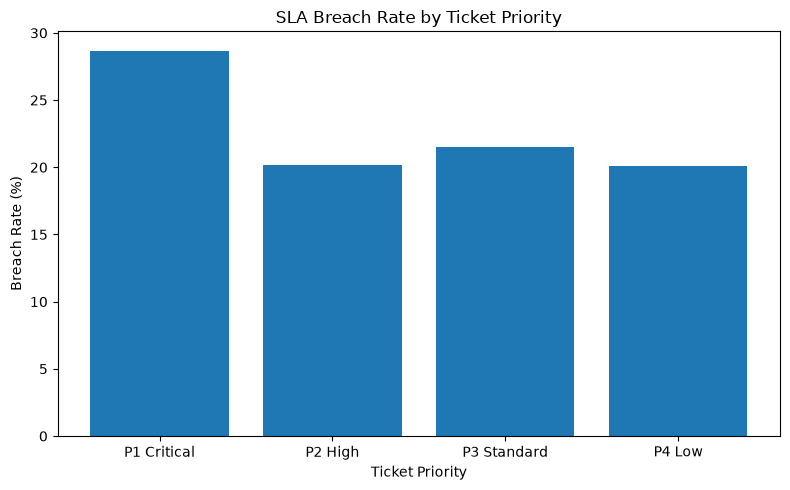

In [45]:
# Create a bar chart showing SLA breach rate by priority level
plt.figure(figsize=(8, 5))

plt.bar(
    priority_summary["PriorityLabel"],
    priority_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Ticket Priority")
plt.xlabel("Ticket Priority")
plt.ylabel("Breach Rate (%)")

# Improve chart readability
plt.xticks(rotation=0)
plt.tight_layout()

# Display the chart
plt.show()

The chart shows that `P1 Critical` tickets have the highest SLA breach rate at approximately **28.68%**.

The other priority levels have lower and fairly similar breach rates, ranging from about **20% to 22%**.

This suggests that critical tickets face a greater risk of SLA breach, possibly because they have much shorter response and resolution deadlines. Priority therefore appears to have a meaningful relationship with SLA breach risk and should be considered during modelling.

,CategoryName,TotalTickets,BreachedTickets,BreachRate
3,Document Request,415,101,24.337349
2,Complaint,306,74,24.183007
4,Insurance Query,706,154,21.813031
1,Billing Issue,873,180,20.618557
0,Appointment Change,1200,245,20.416667


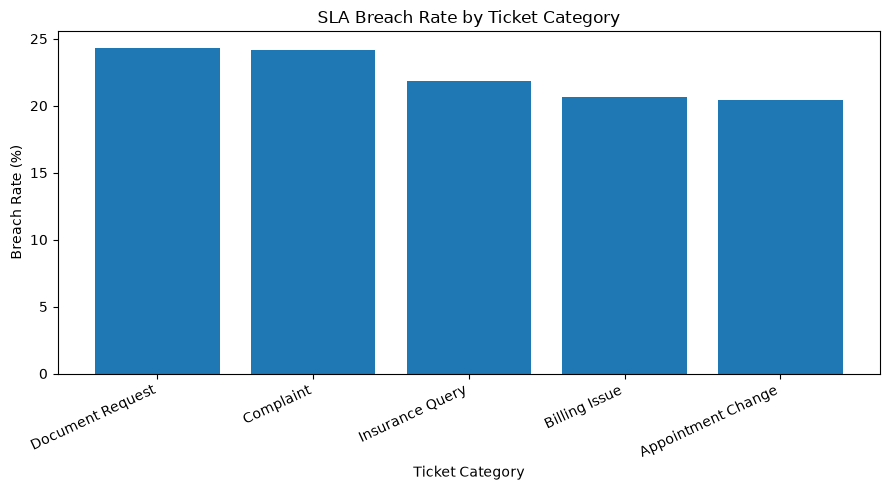

In [47]:
# Calculate SLA breach statistics for each ticket category
category_summary = model_data.groupby("CategoryName").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
category_summary["BreachRate"] = category_summary["BreachRate"] * 100

# Sort categories from highest to lowest breach rate
category_summary = category_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(category_summary)

# Create a bar chart showing SLA breach rate by ticket category
plt.figure(figsize=(9, 5))

plt.bar(
    category_summary["CategoryName"],
    category_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Ticket Category")
plt.xlabel("Ticket Category")
plt.ylabel("Breach Rate (%)")

# Rotate category labels for readability
plt.xticks(rotation=25, ha="right")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates show some variation across ticket categories.

- `Document Request` has the highest breach rate at approximately **24.34%**.
- `Complaint` follows closely at approximately **24.18%**.
- `Insurance Query` records a breach rate of approximately **21.81%**.
- `Billing Issue` and `Appointment Change` have the lowest breach rates at approximately **20.62%** and **20.42%**, respectively.

Although the differences between categories are moderate, Document Requests and Complaints appear more likely to breach SLA. This suggests that ticket category may provide useful information for predicting SLA breach risk.

,Channel,TotalTickets,BreachedTickets,BreachRate
2,Phone,905,216,23.867403
1,Form,397,89,22.418136
3,Portal,977,203,20.777892
0,Email,1221,246,20.147420


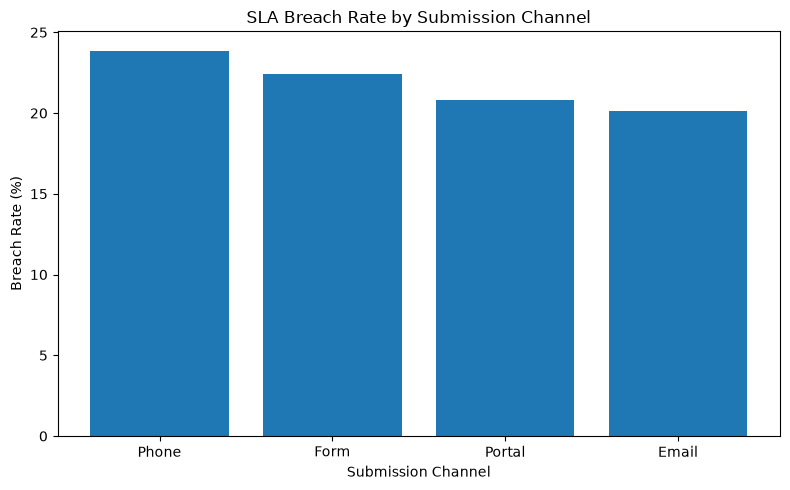

In [48]:
# Calculate SLA breach statistics for each submission channel
channel_summary = model_data.groupby("Channel").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
channel_summary["BreachRate"] = channel_summary["BreachRate"] * 100

# Sort channels from highest to lowest breach rate
channel_summary = channel_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(channel_summary)

# Create a bar chart showing SLA breach rate by submission channel
plt.figure(figsize=(8, 5))

plt.bar(
    channel_summary["Channel"],
    channel_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates differ across ticket submission channels.

- `Phone` has the highest breach rate at approximately **23.87%**.
- `Form` follows with a breach rate of approximately **22.42%**.
- `Portal` records a breach rate of approximately **20.78%**.
- `Email` has the lowest breach rate at approximately **20.15%**.

The differences are not extremely large, but tickets submitted by Phone and Form appear more likely to breach SLA than those submitted through Portal or Email.

This suggests that the submission channel may provide useful information for predicting SLA breach risk.

,ContractTier,TotalTickets,BreachedTickets,BreachRate
2,Standard,1662,364,21.901324
1,Premium,1295,277,21.389961
0,Enterprise,543,113,20.810313


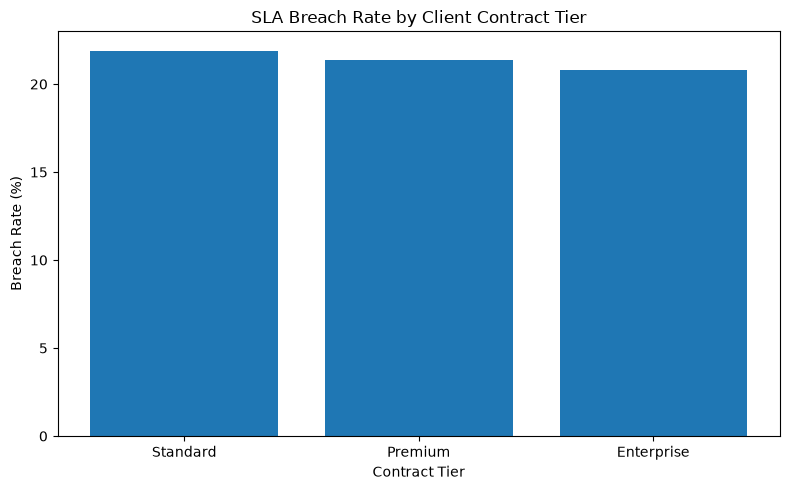

In [49]:
# Calculate SLA breach statistics for each contract tier
contract_summary = model_data.groupby("ContractTier").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
contract_summary["BreachRate"] = contract_summary["BreachRate"] * 100

# Sort contract tiers from highest to lowest breach rate
contract_summary = contract_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(contract_summary)

# Create a bar chart showing SLA breach rate by contract tier
plt.figure(figsize=(8, 5))

plt.bar(
    contract_summary["ContractTier"],
    contract_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Client Contract Tier")
plt.xlabel("Contract Tier")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates are relatively similar across the three client contract tiers.

- `Standard` clients have the highest breach rate at approximately **21.90%**.
- `Premium` clients record a breach rate of approximately **21.39%**.
- `Enterprise` clients have the lowest breach rate at approximately **20.81%**.

The differences between the contract tiers are small, suggesting that contract tier alone may not strongly separate breached and non-breached tickets.

However, contract tier still remains important because it determines the SLA response and resolution requirements for each ticket and may interact with other features such as ticket priority.

,Hub,TotalTickets,BreachedTickets,BreachRate
0,Birmingham,736,173,23.505435
3,Manchester,1346,312,23.179792
1,Edinburgh,817,156,19.094247
2,Leeds,601,113,18.801997


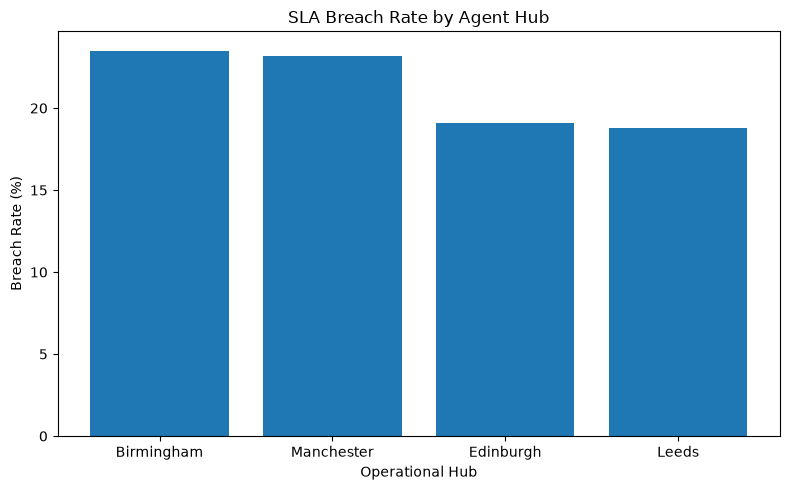

In [50]:
# Calculate SLA breach statistics for each operational hub
hub_summary = model_data.groupby("Hub").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
hub_summary["BreachRate"] = hub_summary["BreachRate"] * 100

# Sort hubs from highest to lowest breach rate
hub_summary = hub_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(hub_summary)

# Create a bar chart showing SLA breach rate by operational hub
plt.figure(figsize=(8, 5))

plt.bar(
    hub_summary["Hub"],
    hub_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Hub")
plt.xlabel("Operational Hub")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the four operational hubs.

- `Birmingham` has the highest breach rate at approximately **23.51%**.
- `Manchester` follows closely at approximately **23.18%**.
- `Edinburgh` records a lower breach rate of approximately **19.09%**.
- `Leeds` has the lowest breach rate at approximately **18.80%**.

The results suggest that tickets handled by Birmingham and Manchester experience higher SLA breach rates than those handled by Edinburgh and Leeds.

This may reflect differences in workload, staffing, capacity, or ticket mix across the hubs. However, the hub alone does not explain the cause of the breaches and should be considered alongside other operational features.

,DailyCapacity,TotalTickets,BreachedTickets,BreachRate
0,6,52,8,15.384615
1,8,63,13,20.634921
2,10,47,6,12.765957
3,11,24,6,25.000000
4,13,179,33,18.435754
5,14,215,50,23.255814
6,15,63,11,17.460317
7,16,96,23,23.958333
8,17,90,25,27.777778
9,18,331,73,22.054381


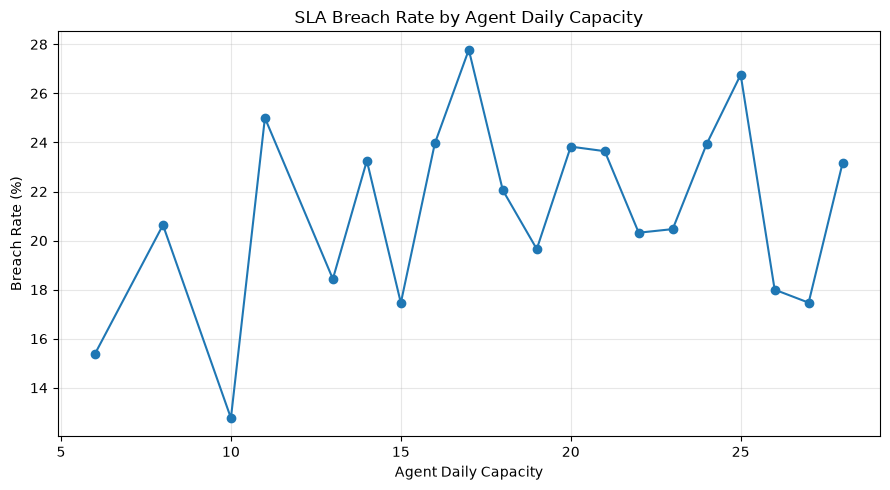

In [51]:
# Calculate SLA breach statistics for each agent daily capacity level
capacity_summary = model_data.groupby("DailyCapacity").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
capacity_summary["BreachRate"] = capacity_summary["BreachRate"] * 100

# Sort the results by daily capacity
capacity_summary = capacity_summary.sort_values("DailyCapacity")

# Display the summary table
display(capacity_summary)

# Create a line chart showing SLA breach rate across daily capacity levels
plt.figure(figsize=(9, 5))

plt.plot(
    capacity_summary["DailyCapacity"],
    capacity_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Daily Capacity")
plt.xlabel("Agent Daily Capacity")
plt.ylabel("Breach Rate (%)")

# Add a light grid to make the trend easier to read
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates fluctuate across different agent daily capacity levels, but there is no clear upward or downward trend.

Some capacity levels, such as 17 and 25 tickets per day, show relatively high breach rates, while others, such as 6, 10, 26, and 27 tickets per day, show lower breach rates.

However, several capacity levels have relatively small numbers of tickets, which can cause the breach rate to vary more sharply.

Overall, `DailyCapacity` alone does not appear to have a strong or consistent relationship with SLA breach risk. Its effect may be more meaningful when considered together with other operational factors such as ticket priority, hub, team, and actual workload.

,CreatedDayOfWeek,TotalTickets,BreachedTickets,BreachRate
1,Monday,468,101,21.581197
5,Tuesday,493,95,19.269777
6,Wednesday,512,105,20.507812
4,Thursday,473,101,21.353066
0,Friday,519,123,23.699422
2,Saturday,522,105,20.114943
3,Sunday,513,124,24.171540


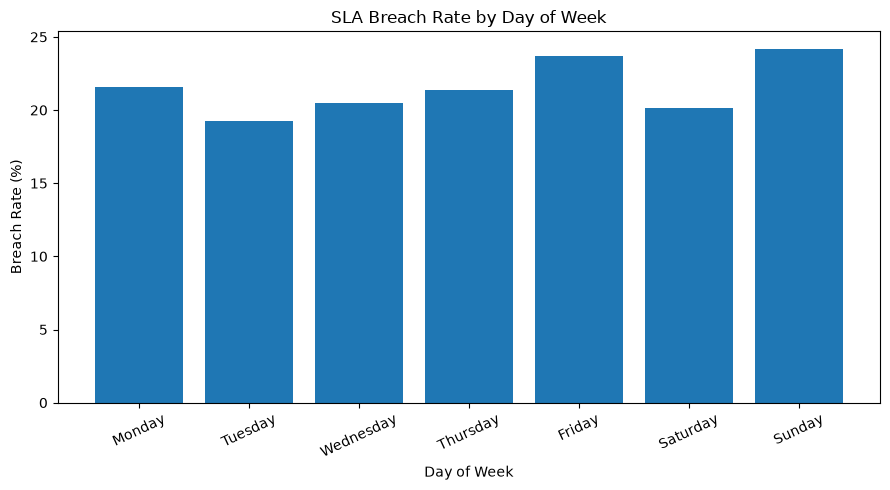

In [52]:
# Set the correct day-of-week order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate SLA breach statistics for each day of the week
day_summary = model_data.groupby("CreatedDayOfWeek").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
day_summary["BreachRate"] = day_summary["BreachRate"] * 100

# Convert the day column to an ordered category
day_summary["CreatedDayOfWeek"] = pd.Categorical(
    day_summary["CreatedDayOfWeek"],
    categories=day_order,
    ordered=True
)

# Sort the results in calendar order
day_summary = day_summary.sort_values("CreatedDayOfWeek")

# Display the summary table
display(day_summary)

# Create a bar chart showing SLA breach rate by day of week
plt.figure(figsize=(9, 5))

plt.bar(
    day_summary["CreatedDayOfWeek"].astype(str),
    day_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Breach Rate (%)")

# Rotate labels slightly for readability
plt.xticks(rotation=25)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the days of the week.

- `Sunday` has the highest breach rate at approximately **24.17%**.
- `Friday` follows at approximately **23.70%**.
- `Monday` and `Thursday` show moderate breach rates of approximately **21.58%** and **21.35%**.
- `Tuesday` records the lowest breach rate at approximately **19.27%**.
- `Wednesday` and `Saturday` fall in between at approximately **20.51%** and **20.11%**.

The pattern suggests that tickets created toward the end of the week, especially on Friday and Sunday, may face a slightly higher risk of SLA breach.

However, the differences are not extreme, so day of week is likely to be more useful when combined with other features rather than used on its own.

,CreatedHour,TotalTickets,BreachedTickets,BreachRate
0,0,130,27,20.769231
1,1,139,34,24.460432
2,2,148,23,15.540541
3,3,159,35,22.012579
4,4,136,26,19.117647
5,5,143,28,19.580420
6,6,130,26,20.000000
7,7,163,42,25.766871
8,8,151,31,20.529801
9,9,153,29,18.954248


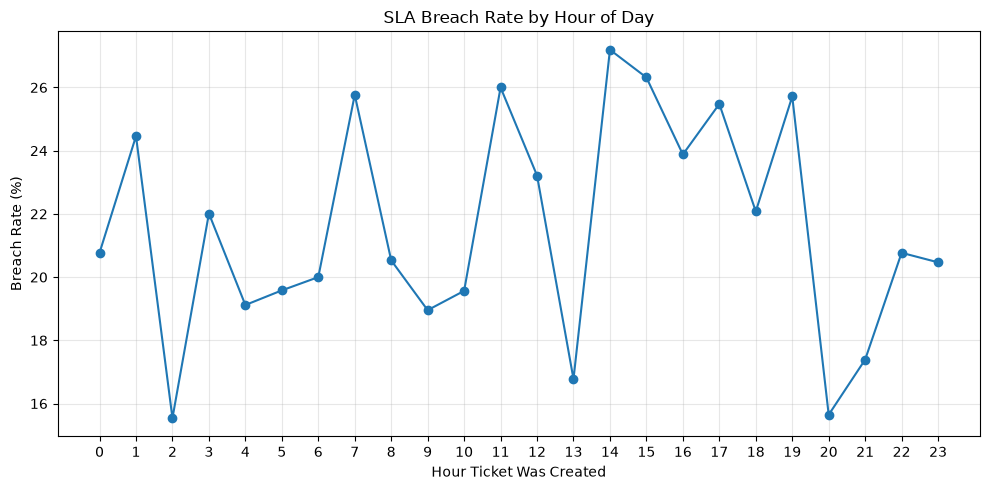

In [53]:
# Calculate SLA breach statistics for each ticket creation hour
hour_summary = model_data.groupby("CreatedHour").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
hour_summary["BreachRate"] = hour_summary["BreachRate"] * 100

# Sort the results by hour of day
hour_summary = hour_summary.sort_values("CreatedHour")

# Display the summary table
display(hour_summary)

# Create a line chart showing SLA breach rate by hour of day
plt.figure(figsize=(10, 5))

plt.plot(
    hour_summary["CreatedHour"],
    hour_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Hour of Day")
plt.xlabel("Hour Ticket Was Created")
plt.ylabel("Breach Rate (%)")

# Show each hour clearly on the x-axis
plt.xticks(range(0, 24))

# Add a light grid to make the pattern easier to read
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary noticeably depending on the hour a ticket was created.

- The highest breach rate occurs at `14:00` (2 PM) at approximately **27.19%**.
- Other relatively high breach rates appear around `15:00`, `11:00`, `7:00`, `17:00`, and `19:00`, ranging from about **25% to 26%**.
- Some of the lowest breach rates occur at `02:00`, `20:00`, `13:00`, and `21:00`.

There is no consistent increase or decrease in SLA breach rate throughout the day. Instead, the pattern fluctuates across different hours.

This suggests that ticket creation hour may contain useful predictive information, but its relationship with SLA breach risk is not linear and should be considered together with other features.

,CreatedMonth,TotalTickets,BreachedTickets,BreachRate
0,1,405,94,23.209877
1,2,352,78,22.159091
2,3,392,87,22.193878
3,4,268,57,21.268657
4,5,259,61,23.552124
5,6,261,50,19.157088
6,7,248,39,15.725806
7,8,289,67,23.183391
8,9,248,57,22.983871
9,10,269,61,22.676580


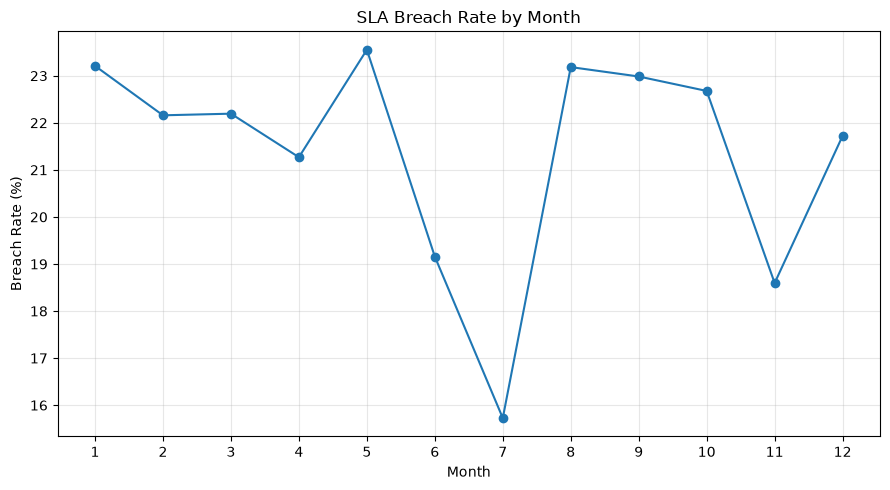

In [54]:
# Calculate SLA breach statistics for each creation month
month_summary = model_data.groupby("CreatedMonth").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate from decimal to percentage
month_summary["BreachRate"] = month_summary["BreachRate"] * 100

# Sort the results by month number
month_summary = month_summary.sort_values("CreatedMonth")

# Display the summary table
display(month_summary)

# Create a line chart showing SLA breach rate by month
plt.figure(figsize=(9, 5))

plt.plot(
    month_summary["CreatedMonth"],
    month_summary["BreachRate"],
    marker="o"
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Month")
plt.xlabel("Month")
plt.ylabel("Breach Rate (%)")

# Show all month numbers clearly on the x-axis
plt.xticks(range(1, 13))

# Add a light grid for readability
plt.grid(alpha=0.3)

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across the months of the year.

- `May` records the highest breach rate at approximately **23.55%**.
- `January` and `August` also show relatively high breach rates at approximately **23.21%** and **23.18%**.
- `September` and `October` remain fairly high at around **23%**.
- `July` has the lowest breach rate at approximately **15.73%**.
- `November` and `June` also show relatively low breach rates at approximately **18.60%** and **19.16%**.

The results suggest that SLA breach risk changes across the year, with some months experiencing higher breach rates than others.

This indicates that month may contain useful predictive information, although the pattern should not be interpreted as a clear seasonal trend without further investigation into ticket volume and other operational factors.

,SLACreditClause,TotalTickets,BreachedTickets,BreachRate
0,No Credit Clause,2189,475,21.699406
1,Credit Clause,1311,279,21.281465


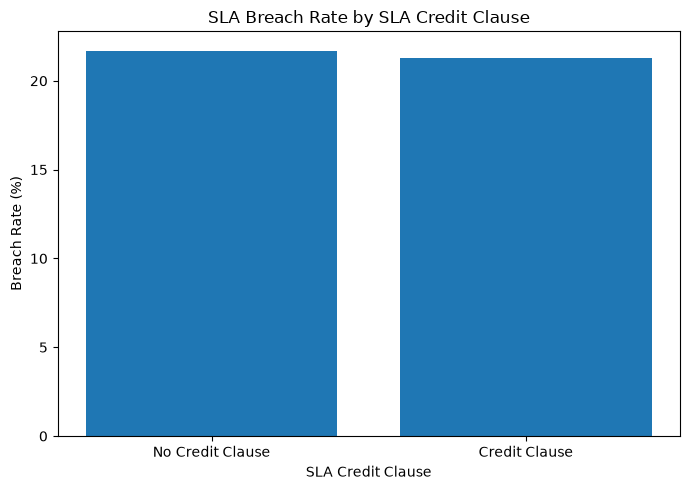

In [55]:
# Calculate SLA breach statistics by SLA credit clause
credit_summary = model_data.groupby("SLACreditClause").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
credit_summary["BreachRate"] = credit_summary["BreachRate"] * 100

# Replace the numeric values with readable labels
credit_summary["SLACreditClause"] = credit_summary["SLACreditClause"].map({
    0: "No Credit Clause",
    1: "Credit Clause"
})

# Display the summary table
display(credit_summary)

# Create a bar chart showing SLA breach rate by SLA credit clause
plt.figure(figsize=(7, 5))

plt.bar(
    credit_summary["SLACreditClause"],
    credit_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by SLA Credit Clause")
plt.xlabel("SLA Credit Clause")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates are almost the same for clients with and without an SLA credit clause.

- Clients with `No Credit Clause` have a breach rate of approximately **21.70%**.
- Clients with a `Credit Clause` have a breach rate of approximately **21.28%**.

The difference between the two groups is very small, suggesting that `SLACreditClause` by itself does not strongly separate breached and non-breached tickets.

However, the feature may still provide useful information when combined with other variables such as contract tier and ticket priority during modelling.

,TeamID,TotalTickets,BreachedTickets,BreachRate
2,6,736,173,23.505435
0,1,1346,312,23.179792
3,8,817,156,19.094247
1,4,601,113,18.801997


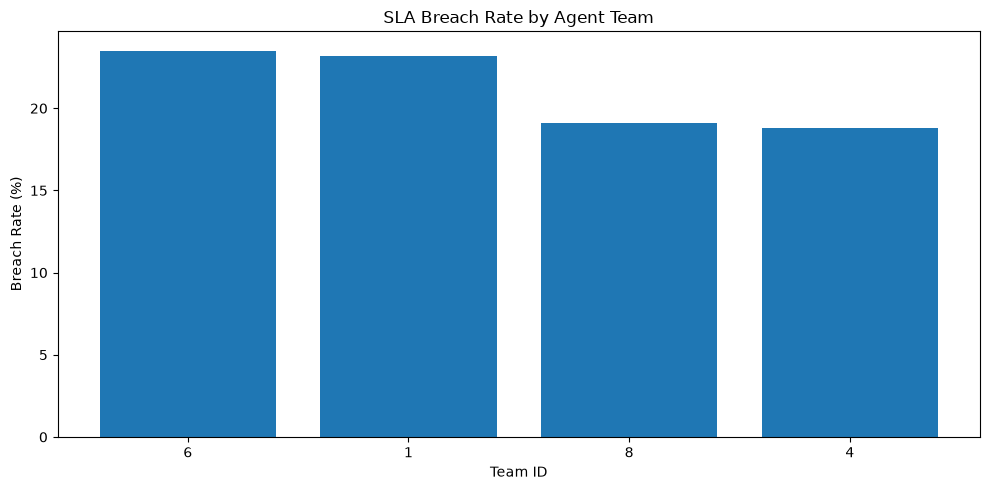

In [56]:
# Calculate SLA breach statistics for each team
team_summary = model_data.groupby("TeamID").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert the breach rate from decimal to percentage
team_summary["BreachRate"] = team_summary["BreachRate"] * 100

# Sort teams from highest to lowest breach rate
team_summary = team_summary.sort_values(
    by="BreachRate",
    ascending=False
)

# Display the summary table
display(team_summary)

# Create a bar chart showing SLA breach rate by team
plt.figure(figsize=(10, 5))

plt.bar(
    team_summary["TeamID"].astype(str),
    team_summary["BreachRate"]
)

# Add chart title and axis labels
plt.title("SLA Breach Rate by Agent Team")
plt.xlabel("Team ID")
plt.ylabel("Breach Rate (%)")

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

SLA breach rates vary across operational teams.

- `Team 6` has the highest breach rate at approximately **23.51%**.
- `Team 1` follows closely at approximately **23.18%**.
- `Team 8` records a lower breach rate of approximately **19.09%**.
- `Team 4` has the lowest breach rate at approximately **18.80%**.

The difference between the highest- and lowest-performing teams is noticeable, suggesting that team assignment may be associated with SLA breach risk.

However, these results should be interpreted together with hub, workload, ticket priority, and other operational factors, since team-level differences may reflect the type and volume of tickets handled rather than team performance alone.

In [57]:
# Check how many hubs are associated with each TeamID
team_hub_check = model_data.groupby("TeamID")["Hub"].nunique()

# Display the number of unique hubs linked to each team
team_hub_check

TeamID
1    1
4    1
6    1
8    1
Name: Hub, dtype: int64

In [58]:
# Display the actual TeamID and Hub combinations
team_hub_mapping = model_data[
    ["TeamID", "Hub"]
].drop_duplicates().sort_values("TeamID")

# View the team-to-hub mapping
team_hub_mapping

,TeamID,Hub
1,1,Manchester
2,4,Leeds
9,6,Birmingham
0,8,Edinburgh


Each operational team is associated with exactly one hub:

- `Team 1` → Manchester
- `Team 4` → Leeds
- `Team 6` → Birmingham
- `Team 8` → Edinburgh

This shows that `TeamID` and `Hub` contain overlapping information in this dataset.

Since both features represent the same operational grouping, including both in the model would introduce unnecessary redundancy. `Hub` will be preferred because it provides a more descriptive and interpretable representation of the operational location.

## Exploratory Data Analysis Summary

The exploratory analysis examined SLA breach patterns across ticket, client, agent, and time-based features.

The main findings are:

- `P1 Critical` tickets recorded the highest SLA breach rate at approximately **28.68%**, suggesting that ticket priority is an important indicator of breach risk.
- `Document Request` and `Complaint` tickets had the highest breach rates among ticket categories, at approximately **24%**.
- Tickets submitted through `Phone` had the highest breach rate at approximately **23.87%**, while `Email` had the lowest at approximately **20.15%**.
- SLA breach rates were very similar across client contract tiers, ranging from approximately **20.81% to 21.90%**.
- `Birmingham` and `Manchester` showed higher breach rates than `Edinburgh` and `Leeds`.
- `DailyCapacity` did not show a clear or consistent relationship with SLA breach risk when examined on its own.
- SLA breach rates varied across the week, with `Sunday` and `Friday` recording the highest rates.
- Ticket creation hour showed noticeable variation in breach rates, although there was no clear linear pattern across the day.
- Monthly breach rates also varied, with `May` among the highest and `July` recording the lowest rate.
- SLA credit clause status showed very little difference in breach rates between clients with and without a credit clause.
- `TeamID` and `Hub` were found to represent the same operational grouping, with each team belonging to exactly one hub. To avoid redundant information, `Hub` will be preferred over `TeamID` during modelling.

Overall, the analysis suggests that ticket priority, category, submission channel, hub, and time-related features may provide useful information for predicting SLA breach risk. Other variables such as contract tier, daily capacity, and SLA credit clause may have weaker individual relationships but could still contribute when combined with other features in the machine learning model.

### Model Preparation

In [59]:
# Select the features that will be used to predict SLA breach
features = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "SLACreditClause",
    "Hub",
    "DailyCapacity",
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth"
]

# Create the feature dataset X
X = model_data[features].copy()

# Create the target variable y
y = model_data["SLABreached"].copy()

# Check the dimensions of the feature and target datasets
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3500, 10)
y shape: (3500,)


In [60]:
# Preview the features selected for modelling
X.head()

,PriorityLabel,CategoryName,Channel,ContractTier,SLACreditClause,Hub,DailyCapacity,CreatedHour,CreatedDayOfWeek,CreatedMonth
0,P3 Standard,Document Request,Phone,Standard,0,Edinburgh,16,23,Wednesday,7
1,P1 Critical,Billing Issue,Portal,Standard,0,Manchester,8,23,Wednesday,11
2,P3 Standard,Insurance Query,Portal,Standard,0,Leeds,21,5,Thursday,8
3,P2 High,Appointment Change,Form,Premium,1,Manchester,27,13,Tuesday,12
4,P2 High,Insurance Query,Phone,Standard,0,Leeds,26,3,Saturday,2


In [61]:
# Confirm the distribution of the target variable
y.value_counts()

SLABreached
0    2746
1     754
Name: count, dtype: int64

The final modelling dataset contains **3,500 ticket records and 10 predictor features**.

The selected features include ticket characteristics, client contract information, agent operational information, and ticket creation time features. All selected variables are available before the final SLA outcome is known, helping to reduce the risk of data leakage.

The target variable remains moderately imbalanced:

- `0` (No SLA Breach): **2,746 tickets**
- `1` (SLA Breach): **754 tickets**

This imbalance will be considered when evaluating model performance, with greater attention given to metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

### Train/Test Split

In [62]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of the data will be used for training and 20% for testing
# Stratify=y keeps the SLA breach proportion similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the size of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2800, 10)
X_test shape: (700, 10)
y_train shape: (2800,)
y_test shape: (700,)


In [63]:
# Check SLA breach percentages in the training and testing sets
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
SLABreached
0    78.464286
1    21.535714
Name: proportion, dtype: float64

Testing target distribution:
SLABreached
0    78.428571
1    21.571429
Name: proportion, dtype: float64


The dataset was successfully divided into training and testing sets using an 80/20 split.

- The training set contains **2,800 records**.
- The testing set contains **700 records**.
- Both datasets contain the same 10 predictor features.

Stratification preserved the SLA breach distribution across both sets:

- Training set: approximately **21.54% breached** and **78.46% not breached**
- Testing set: approximately **21.57% breached** and **78.43% not breached**

This ensures that both datasets have a similar class distribution and provides a fair basis for model training and evaluation.

### Data Preprocessing

In [64]:
# Define categorical features that need One-Hot Encoding
categorical_features = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "Hub",
    "CreatedDayOfWeek"
]

# Define numerical features that will be standardised
numerical_features = [
    "DailyCapacity",
    "CreatedHour",
    "CreatedMonth"
]

# Define the binary feature
# This is already represented as 0 and 1, so no encoding is required
binary_features = [
    "SLACreditClause"
]

In [65]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        
        # Convert categorical features into numerical dummy variables
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        
        # Standardise numerical features
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        
        # Keep the binary feature unchanged
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

# Display the preprocessing setup
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

The preprocessing transformer was created successfully.

- Categorical features will be processed using `OneHotEncoder`.
- Numerical features will be standardised using `StandardScaler`.
- The binary `SLACreditClause` feature will be passed through without additional transformation.

This preprocessing setup will be included in the machine learning pipeline so that the same transformations are applied consistently during model training and testing.

### Baseline Model: Logistic Regression

In [68]:
# Import Logistic Regression and Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create the Logistic Regression pipeline
# The preprocessing step prepares the features before model training
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the baseline model using the training data
logistic_model.fit(X_train, y_train)

# Confirm that model training is complete
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [69]:
# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Generate predicted classes for the test data
y_pred = logistic_model.predict(X_test)

# Generate predicted probabilities for the positive class (SLA breach = 1)
# These probabilities are required for calculating ROC-AUC
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display the main evaluation metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7843
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5198


c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [70]:
# Display the full classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       549
           1       0.00      0.00      0.00       151

    accuracy                           0.78       700
   macro avg       0.39      0.50      0.44       700
weighted avg       0.62      0.78      0.69       700



c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\olade\Downloads\DS Internship Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [71]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix values
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[549   0]
 [151   0]]


The baseline Logistic Regression model achieved an accuracy of approximately **78.43%**. However, the accuracy is misleading because the model predicted every test observation as a non-breached ticket.

The confusion matrix shows:

- **549 true negatives** – non-breached tickets correctly classified
- **0 false positives**
- **151 false negatives** – breached tickets incorrectly classified as non-breached
- **0 true positives** – no actual SLA breaches were identified

As a result, precision, recall, and F1-score for the SLA breach class are all **0**.

The ROC-AUC score of approximately **0.52** also indicates that the baseline model has very limited ability to distinguish between breached and non-breached tickets.

This demonstrates why accuracy alone is not an appropriate evaluation metric for this imbalanced classification problem. The baseline model provides a useful performance floor but requires improvement before it can support proactive SLA breach detection.

### Handle the class imbalance

In [72]:
# Create a class-weighted Logistic Regression pipeline
# class_weight="balanced" gives more importance to the minority SLA breach class
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Train the class-weighted Logistic Regression model
balanced_logistic_model.fit(X_train, y_train)

# Confirm that training is complete
print("Class-weighted Logistic Regression model trained successfully.")

Class-weighted Logistic Regression model trained successfully.


In [73]:
# Generate class predictions using the class-weighted model
y_pred_balanced = balanced_logistic_model.predict(X_test)

# Generate predicted probabilities for SLA breach
y_prob_balanced = balanced_logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)
balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)
balanced_roc_auc = roc_auc_score(y_test, y_prob_balanced)

# Display the evaluation results
print(f"Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall:    {balanced_recall:.4f}")
print(f"F1-Score:  {balanced_f1:.4f}")
print(f"ROC-AUC:   {balanced_roc_auc:.4f}")

Accuracy:  0.5000
Precision: 0.2181
Recall:    0.5099
F1-Score:  0.3056
ROC-AUC:   0.5189


In [74]:
# Display the classification report for both classes
print(classification_report(
    y_test,
    y_pred_balanced,
    zero_division=0
))

# Create and display the confusion matrix
balanced_cm = confusion_matrix(y_test, y_pred_balanced)

print("Confusion Matrix:")
print(balanced_cm)

              precision    recall  f1-score   support

           0       0.79      0.50      0.61       549
           1       0.22      0.51      0.31       151

    accuracy                           0.50       700
   macro avg       0.50      0.50      0.46       700
weighted avg       0.66      0.50      0.54       700

Confusion Matrix:
[[273 276]
 [ 74  77]]


Applying class weighting improved the model's ability to identify SLA breaches compared with the baseline Logistic Regression model.

The class-weighted model achieved:

- Accuracy: **50.00%**
- Precision: **21.81%**
- Recall: **50.99%**
- F1-score: **30.56%**
- ROC-AUC: **51.89%**

The model correctly identified **77 of the 151 actual SLA breaches**, increasing breach recall from 0% in the baseline model to approximately 51%.

However, this improvement came with a high number of false positives. The model incorrectly classified **276 non-breached tickets as SLA breaches**.

Although class weighting improved minority-class detection, the ROC-AUC remained close to 0.50, indicating that Logistic Regression still has limited ability to distinguish between breached and non-breached tickets.

Therefore, the class-weighted Logistic Regression model is not considered suitable as the final model, but it provides a useful benchmark for comparison with more advanced non-linear models.

### XGBoost Classification Model

In [75]:
# Import the XGBoost classifier
from xgboost import XGBClassifier

# Count the number of non-breached and breached tickets in the training set
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

# Calculate the class imbalance weight
# This tells XGBoost to give more importance to the minority breach class
scale_pos_weight = negative_count / positive_count

# Display the calculated weight
print("Scale Pos Weight:", round(scale_pos_weight, 2))

Scale Pos Weight: 3.64


In [76]:
# Create the XGBoost classification pipeline
# The same preprocessing steps are applied before training the model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        # Train an XGBoost classifier
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

# Train the XGBoost model using the training data
xgb_model.fit(X_train, y_train)

# Confirm that training is complete
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


The XGBoost model is evaluated using the same metrics applied to Logistic Regression.

Using the same evaluation measures allows the models to be compared fairly and helps determine whether the non-linear XGBoost model provides better detection of SLA breaches.

In [77]:
# Generate class predictions using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Generate predicted probabilities for SLA breach
# These probabilities are used to calculate ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

# Display the main evaluation metrics
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

Accuracy:  0.6157
Precision: 0.2318
Recall:    0.3377
F1-Score:  0.2749
ROC-AUC:   0.5211


In [78]:
# Display the full classification report

print(
    classification_report(
        y_test,
        y_pred_xgb,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.79      0.69      0.74       549
           1       0.23      0.34      0.27       151

    accuracy                           0.62       700
   macro avg       0.51      0.51      0.51       700
weighted avg       0.67      0.62      0.64       700



The XGBoost model achieved an accuracy of approximately **61.57%**, with a precision of **23.18%**, recall of **33.77%**, F1-score of **27.49%**, and ROC-AUC of **52.11%**.

Compared with the class-weighted Logistic Regression model, XGBoost improved accuracy and slightly improved precision. However, recall decreased from approximately 51% to 34%, meaning that XGBoost identified fewer of the actual SLA breaches.

The ROC-AUC score also remained close to 0.50, indicating that the model still has limited ability to distinguish between breached and non-breached tickets.

Therefore, XGBoost does not currently provide a strong improvement over the Logistic Regression benchmark. Further model comparison and feature improvement are required before selecting a final model.

### Initial Model Comparison

In [79]:
# Create a comparison table containing the evaluation results
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        balanced_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        balanced_recall,
        xgb_recall
    ],
    "F1-Score": [
        f1,
        balanced_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc,
        xgb_roc_auc
    ]
})

# Round the values to four decimal places for easier comparison
model_comparison = model_comparison.round(4)

# Display the model comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7843,0.0000,0.0000,0.0000,0.5198
1,Weighted Logistic Regression,0.5000,0.2181,0.5099,0.3056,0.5189
2,XGBoost,0.6157,0.2318,0.3377,0.2749,0.5211


The initial model comparison shows that none of the three models currently provides strong predictive performance.

- The baseline Logistic Regression achieved the highest accuracy at **78.43%**, but it failed to identify any SLA breaches, resulting in 0 precision, recall, and F1-score for the breach class.
- The class-weighted Logistic Regression achieved the highest recall at approximately **50.99%** and the highest F1-score at **30.56%**, making it better at identifying actual SLA breaches.
- XGBoost improved accuracy to **61.57%** and achieved the highest ROC-AUC at **52.11%**, but its recall was lower than the class-weighted Logistic Regression.

All ROC-AUC scores remain close to **0.50**, indicating that the current feature set has limited ability to separate breached and non-breached tickets.

The results suggest that improving the available predictive features may be more important than simply applying more complex algorithms.

### Additional Feature Engineering: SLA Time Window

In [80]:
# Convert SLADueAt to datetime format in the modelling dataset
# CreatedAt was already converted earlier
model_data["SLADueAt"] = pd.to_datetime(model_data["SLADueAt"])

# Calculate the total number of hours between ticket creation and the SLA deadline
model_data["SLAWindowHours"] = (
    model_data["SLADueAt"] - model_data["CreatedAt"]
).dt.total_seconds() / 3600

# Preview the new SLA time-window feature
model_data[
    [
        "CreatedAt",
        "SLADueAt",
        "PriorityLabel",
        "ContractTier",
        "SLAWindowHours"
    ]
].head()

,CreatedAt,SLADueAt,PriorityLabel,ContractTier,SLAWindowHours
0,2024-07-24 23:41:00,2024-07-27 23:41:00,P3 Standard,Standard,72.0
1,2024-11-06 23:45:00,2024-11-07 07:45:00,P1 Critical,Standard,8.0
2,2024-08-01 05:39:00,2024-08-04 05:39:00,P3 Standard,Standard,72.0
3,2024-12-03 13:22:00,2024-12-04 01:22:00,P2 High,Premium,12.0
4,2023-02-11 03:56:00,2023-02-12 03:56:00,P2 High,Standard,24.0


In [81]:
# Examine the distribution of the SLA time window
model_data["SLAWindowHours"].describe()

count    3500.000000
mean       48.454857
std        31.082646
min         2.000000
25%        24.000000
50%        48.000000
75%        72.000000
max       120.000000
Name: SLAWindowHours, dtype: float64

In [82]:
# Compare SLA breach rates across different SLA time windows
sla_window_summary = model_data.groupby("SLAWindowHours").agg(
    TotalTickets=("SLABreached", "count"),
    BreachedTickets=("SLABreached", "sum"),
    BreachRate=("SLABreached", "mean")
).reset_index()

# Convert breach rate to percentage
sla_window_summary["BreachRate"] = sla_window_summary["BreachRate"] * 100

# Sort by SLA window length
sla_window_summary = sla_window_summary.sort_values("SLAWindowHours")

# Display the summary
sla_window_summary

,SLAWindowHours,TotalTickets,BreachedTickets,BreachRate
0,2.0,32,4,12.500000
1,4.0,109,34,31.192661
2,8.0,234,55,23.504274
3,12.0,285,54,18.947368
4,24.0,750,167,22.266667
5,48.0,734,156,21.253406
6,72.0,1003,216,21.535394
7,96.0,167,33,19.760479
8,120.0,186,35,18.817204


The available SLA time window varies considerably across tickets, ranging from **2 hours to 120 hours**, with an average of approximately **48.45 hours**.

SLA breach rates also vary across the different time windows. Tickets with a `4-hour` SLA window recorded the highest breach rate at approximately **31.19%**, while most other SLA windows recorded breach rates between approximately 19% and 24%.

The shortest 2-hour SLA window recorded a lower breach rate of 12.50%, although this group contains relatively few tickets and should therefore be interpreted cautiously.

There is no simple pattern showing that shorter SLA windows always result in higher breach rates. However, `SLAWindowHours` directly represents the amount of time available to resolve a ticket and provides useful business information that is not explicitly represented by a single existing feature.

The feature will therefore be included in the next modelling iteration to assess whether it improves predictive performance when combined with the other ticket, client, agent, and time-based features.

In [83]:
# Update the modelling features to include the SLA time window
features_updated = [
    "PriorityLabel",
    "CategoryName",
    "Channel",
    "ContractTier",
    "SLACreditClause",
    "Hub",
    "DailyCapacity",
    "CreatedHour",
    "CreatedDayOfWeek",
    "CreatedMonth",
    "SLAWindowHours"
]

# Create the updated feature dataset
X_updated = model_data[features_updated].copy()

# Keep the same target variable
y_updated = model_data["SLABreached"].copy()

# Check the updated dataset dimensions
print("X shape:", X_updated.shape)
print("y shape:", y_updated.shape)

X shape: (3500, 11)
y shape: (3500,)
